## Setup

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH    = "/content/drive/MyDrive/cig_ps.zip"
EXTRACT_DIR = "/content/cig_ps"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Extracted!")
else:
    print("Already extracted.")

BASE = "/content/cig_ps/cig_ps"
TRAIN_DIR = f"{BASE}/train_images"
TEST_DIR = f"{BASE}/test_images"
LABELS_CSV = f"{BASE}/train-labels.csv"
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths OK.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already extracted.
Paths OK.


## Imports

In [2]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)


Device: cuda


## Vocabulary & Encoding
CTC requires a blank token (index 0). All real characters are shifted by +1.

In [17]:
VOCAB = ['2','3','4','5','6','7','8','9',
             'A','B','C','D','E','F','G','H','J','K',
             'M','N','P','Q','R','S','T','U','V','W','X','Y','Z']
VOCAB_SIZE = len(VOCAB)
SEQ_LEN = 6
BLANK_IDX  = 0

# Real chars start at index 1
CHAR2IDX = {c: i + 1 for i, c in enumerate(VOCAB)}
IDX2CHAR = {i + 1: c for i, c in enumerate(VOCAB)}

def encode_label(text):
    return torch.tensor([CHAR2IDX[c] for c in text], dtype=torch.long)

def decode_ctc(indices):
    result = []
    prev = -1
    for idx in indices.tolist():
        if idx != prev:
            if idx != BLANK_IDX:
                result.append(IDX2CHAR.get(idx, '?'))
            prev = idx
    return ''.join(result)

NUM_CLASSES = VOCAB_SIZE + 1   # 32 (31 chars + 1 blank)
print(f"Vocab size: {VOCAB_SIZE}")
print(f"Num classes: {NUM_CLASSES}  (includes CTC blank at index 0)")
print(f"encode 'BU522X': {encode_label('BU522X').tolist()}")
print(f"decode back: {decode_ctc(encode_label('BU522X'))}")


Vocab size: 31
Num classes: 32  (includes CTC blank at index 0)
encode 'BU522X': [10, 26, 4, 1, 1, 29]
decode back: BU52X


## Dataset

In [4]:
ANOMALOUS = {'train-2184.png', 'train-6819.png'}

df = pd.read_csv(LABELS_CSV, index_col=0)
df_clean = df[~df['image'].isin(ANOMALOUS)].copy()
df_clean['text'] = df_clean['text'].str.strip()
df_clean = df_clean.sample(frac=1, random_state=SEED).reset_index(drop=True)

split = int(0.9 * len(df_clean))
df_train = df_clean.iloc[:split].reset_index(drop=True)
df_val   = df_clean.iloc[split:].reset_index(drop=True)
print(f"Train: {len(df_train)}  |  Val: {len(df_val)}")


class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

        self.base_tf = T.Compose([T.Grayscale(), T.ToTensor()])
        self.aug_tf = T.Compose([
            T.Grayscale(),
            T.RandomAffine(degrees=3, translate=(0.02, 0.02), scale=(0.97, 1.03)),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
        ])
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['image'])).convert('RGB')
        tf = self.aug_tf if self.augment else self.base_tf
        img_t = tf(img)                   # (1, 100, 200)
        lbl_t = encode_label(row['text']) # (6,)  — 1-indexed for CTC
        return img_t, lbl_t


class CaptchaTestDataset(Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.files = sorted(os.listdir(img_dir))
        self.tf = T.Compose([T.Grayscale(), T.ToTensor()])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        return self.tf(img), fname


BATCH_SIZE = 64
train_loader = DataLoader(CaptchaDataset(df_train, TRAIN_DIR, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(CaptchaDataset(df_val,   TRAIN_DIR, augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(CaptchaTestDataset(TEST_DIR),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f"Batch image : {imgs.shape}")
print(f"Batch label : {lbls.shape}")


Train: 17998  |  Val: 2000
Batch image : torch.Size([64, 1, 100, 200])
Batch label : torch.Size([64, 6])


## CER Metric

In [5]:
def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            dp[j] = prev if s1[i-1] == s2[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[n]

def compute_cer(preds, targets):
    total_dist = sum(levenshtein(p, t) for p, t in zip(preds, targets))
    total_len  = sum(len(t) for t in targets)
    return total_dist / total_len if total_len > 0 else 0.0


## CRNN Architecture


In [18]:
class CRNN(nn.Module):
    def __init__(self, num_classes=32, rnn_hidden=256, rnn_layers=2):
        super().__init__()

        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1,  64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            # Block 4
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            # Block 5
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # Collapse height
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

        # ── BiLSTM
        self.rnn = nn.LSTM(
            input_size=256,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if rnn_layers > 1 else 0.0,
        )

        # ── Output projection
        self.fc = nn.Linear(rnn_hidden * 2, num_classes)

    def forward(self, x):
        # CNN
        x = self.cnn(x)
        x = self.adaptive_pool(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        # RNN
        x, _ = self.rnn(x)

        # Projection
        x = self.fc(x)
        x = x.permute(1, 0, 2)
        x = x.log_softmax(2)
        return x


# Check
model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.zeros(4, 1, 100, 200).to(DEVICE)
out   = model(dummy)
print(f"Output shape : {out.shape}   (T, B, num_classes)")
print(f"T (time steps) = {out.shape[0]}  — one per column strip")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


Output shape : torch.Size([50, 4, 32])   (T, B, num_classes)
T (time steps) = 50  — one per column strip
Total parameters: 4,196,832


## Loss, Optimizer, Scheduler

In [7]:
ctc_loss  = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS = 40
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

print(f"Loss      : CTCLoss  (blank={BLANK_IDX})")
print(f"Optimizer : AdamW  lr=1e-3  wd=1e-4")
print(f"Scheduler : CosineAnnealingLR  T_max={NUM_EPOCHS}")


Loss      : CTCLoss  (blank=0)
Optimizer : AdamW  lr=1e-3  wd=1e-4
Scheduler : CosineAnnealingLR  T_max=40


## Train & Evaluate Functions

In [20]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0

    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        optimizer.zero_grad()
        log_probs = model(imgs)

        T = log_probs.shape[0]
        B = imgs.shape[0]

        input_lengths  = torch.full((B,), T, dtype=torch.long).to(DEVICE)
        target_lengths = torch.full((B,), SEQ_LEN, dtype=torch.long).to(DEVICE)

        # CTC expects targets as 1-D concatenated tensor
        targets_flat = lbls.reshape(-1)

        loss = ctc_loss(log_probs, targets_flat, input_lengths, target_lengths)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss   = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)

            log_probs = model(imgs)

            T = log_probs.shape[0]
            B = imgs.shape[0]
            input_lengths = torch.full((B,), T, dtype=torch.long).to(DEVICE)
            target_lengths = torch.full((B,), SEQ_LEN, dtype=torch.long).to(DEVICE)
            targets_flat = lbls.reshape(-1)

            loss = ctc_loss(log_probs, targets_flat, input_lengths, target_lengths)
            total_loss += loss.item()

            pred_indices = log_probs.argmax(2)
            pred_indices = pred_indices.permute(1, 0)

            for i in range(B):
                pred_str = decode_ctc(pred_indices[i])
                target_str = decode_ctc(lbls[i])
                all_preds.append(pred_str)
                all_targets.append(target_str)

    cer = compute_cer(all_preds, all_targets)
    return total_loss / len(loader), cer


## Training Loop

In [9]:
history   = {'train_loss': [], 'val_loss': [], 'val_cer': []}
best_cer  = float('inf')
CKPT_PATH = f"{OUTPUT_DIR}/crnn_best.pth"

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val CER':>8} | {'LR':>8} | {'Time':>6}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss            = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_cer     = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)

    lr      = scheduler.get_last_lr()[0]
    elapsed = time.time() - t0

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_cer:>8.4f} | {lr:>8.6f} | {elapsed:>5.1f}s")

    if val_cer < best_cer:
        best_cer = val_cer
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"Best model saved  (CER={best_cer:.4f})")

print(f"\nBest Val CER: {best_cer:.4f}")


Epoch | Train Loss |  Val Loss |  Val CER |       LR |   Time
-----------------------------------------------------------------
    1 |     3.8670 |    3.5904 |   0.9503 | 0.000998 |  46.5s
        ✓ Best model saved  (CER=0.9503)
    2 |     3.5772 |    3.5837 |   0.9455 | 0.000994 |  46.7s
        ✓ Best model saved  (CER=0.9455)
    3 |     3.5750 |    3.5809 |   0.9354 | 0.000986 |  50.3s
        ✓ Best model saved  (CER=0.9354)
    4 |     3.5728 |    3.5789 |   0.9371 | 0.000976 |  52.4s
    5 |     3.5722 |    3.5802 |   0.9457 | 0.000962 |  51.7s
    6 |     3.3869 |    3.2905 |   0.9116 | 0.000946 |  52.5s
        ✓ Best model saved  (CER=0.9116)
    7 |     2.5836 |    2.4260 |   0.7832 | 0.000927 |  51.7s
        ✓ Best model saved  (CER=0.7832)
    8 |     1.5303 |    1.0493 |   0.3371 | 0.000905 |  51.9s
        ✓ Best model saved  (CER=0.3371)
    9 |     0.6776 |    0.3763 |   0.0548 | 0.000881 |  52.6s
        ✓ Best model saved  (CER=0.0548)
   10 |     0.2807 |    0.2

## Training Curves

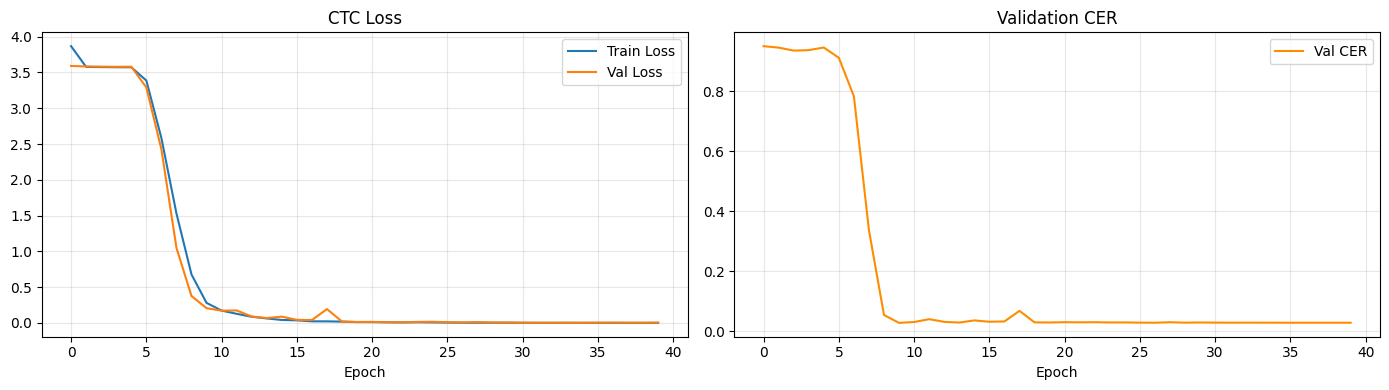

Best Val CER : 0.0286


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('CTC Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_cer'], color='darkorange', label='Val CER')
axes[1].set_title('Validation CER'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/crnn_curves.png", dpi=110)
plt.show()
print(f"Best Val CER : {best_cer:.4f}")


## Qualitative Check — Sample Predictions

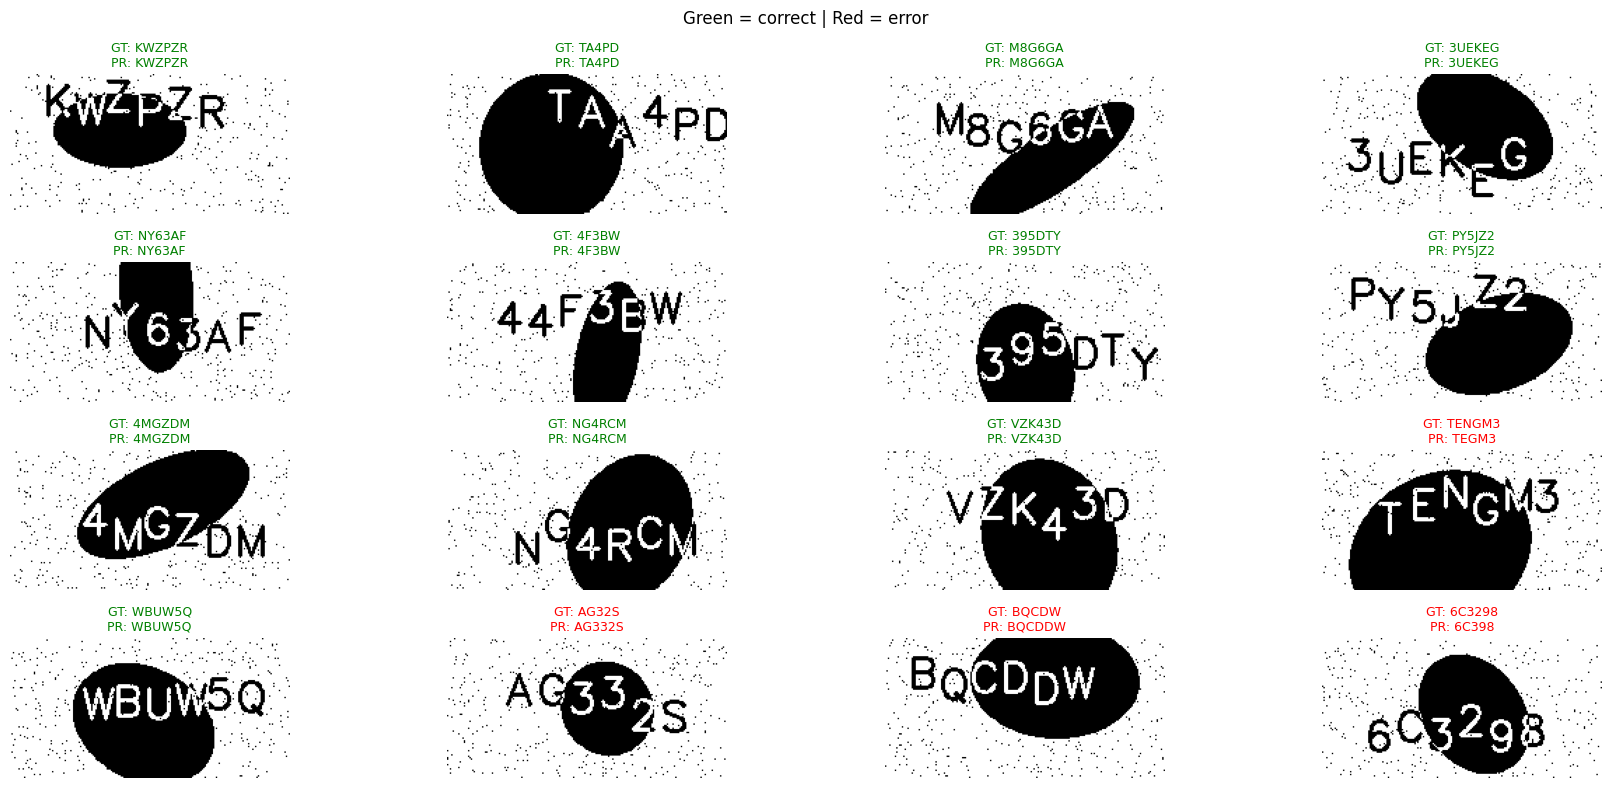

In [11]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# Grab one validation batch
imgs, lbls = next(iter(val_loader))
imgs = imgs.to(DEVICE)

with torch.no_grad():
    log_probs    = model(imgs)
    pred_indices = log_probs.argmax(2).permute(1, 0)  # (B, T)

fig, axes = plt.subplots(4, 4, figsize=(18, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): break
    pred   = decode_ctc(pred_indices[i])
    target = decode_ctc(lbls[i])
    color  = 'green' if pred == target else 'red'
    ax.imshow(imgs[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f"GT: {target}\nPR: {pred}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Green = correct | Red = error', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/crnn_predictions.png", dpi=110)
plt.show()


In [12]:
import shutil
shutil.copy("/content/outputs/crnn_best.pth", "/content/drive/MyDrive/crnn_best.pth")

'/content/drive/MyDrive/crnn_best.pth'

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

predictions = []

with torch.no_grad():
    for imgs, fnames in test_loader:
        imgs         = imgs.to(DEVICE)
        log_probs    = model(imgs)
        pred_indices = log_probs.argmax(2).permute(1, 0)  # (B, T)
        for fname, pred in zip(fnames, pred_indices):
            predictions.append({'image': fname, 'prediction': decode_ctc(pred)})

print(f"Total predictions: {len(predictions)}")

Total predictions: 5000


In [14]:
import csv

SUBMISSION_PATH = f"{OUTPUT_DIR}/submission_priyanshu_24113102.csv"
with open(SUBMISSION_PATH, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['image', 'prediction'])
    writer.writeheader()
    writer.writerows(predictions)

# Copy to Drive so it's not lost when session ends
import shutil
shutil.copy(SUBMISSION_PATH, "/content/drive/MyDrive/submission_priyanshu_24113102.csv")

print(f"Saved to Drive!")

# Preview
import pandas as pd
pd.read_csv(SUBMISSION_PATH).head(10)

Saved to Drive!


,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-10.png,7DUP98
3,test-100.png,75Z4WT
4,test-1000.png,QAKZ7V
5,test-1001.png,R6MERY
6,test-1002.png,CHXX67
7,test-1003.png,9NV2WP
8,test-1004.png,F56TDZ
9,test-1005.png,FTFRX
